In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import pickle

In [4]:
df = pd.read_csv("../data/processed/df")

In [5]:
df.head(5)

,groups,Fecha,Cant,week_day,month,month_day,weekend,beginning_month,cant_lag_1,cant_lag_7,cant_lag_14,cant_lag_30,rolling_7,rolling_30,groups_encoded
0,Accesorios y Dispositivos Médicos,2025-01-04 13:23:37,1,5,1,4,1,1,2.0,1.0,6.0,1.0,1.142857,1.666667,0
1,Accesorios y Dispositivos Médicos,2025-01-04 13:56:59,2,5,1,4,1,1,1.0,1.0,1.0,2.0,1.142857,1.666667,0
2,Accesorios y Dispositivos Médicos,2025-01-04 14:03:15,1,5,1,4,1,1,2.0,1.0,1.0,4.0,1.285714,1.666667,0
3,Accesorios y Dispositivos Médicos,2025-01-04 14:27:28,1,5,1,4,1,1,1.0,1.0,1.0,1.0,1.285714,1.566667,0
4,Accesorios y Dispositivos Médicos,2025-01-04 14:42:15,1,5,1,4,1,1,1.0,1.0,1.0,1.0,1.285714,1.566667,0


In [6]:
df.columns

Index(['groups', 'Fecha', 'Cant', 'week_day', 'month', 'month_day', 'weekend',
       'beginning_month', 'cant_lag_1', 'cant_lag_7', 'cant_lag_14',
       'cant_lag_30', 'rolling_7', 'rolling_30', 'groups_encoded'],
      dtype='object')

In [7]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')

In [8]:
# Split
last_date = df['Fecha'].max()
cut_off_date = last_date - pd.Timedelta(days=30)

train = df[df['Fecha'] <= cut_off_date]
test = df[df['Fecha'] > cut_off_date]

In [9]:
features = ['week_day', 
            'month', 
            'month_day', 
            'weekend', 
            'beginning_month',
            'cant_lag_1', 
            'cant_lag_7', 
            'cant_lag_14', 
            'cant_lag_30',
            'rolling_7', 
            'rolling_30']

X_train = train[features]
y_train = train['Cant']

X_test = test[features]
y_test = test['Cant']

### Modelo XGBRegressor

In [10]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

In [11]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.9187464714050293

In [14]:
rmse = np.sqrt(((y_test - y_pred)**2).mean())
rmse

np.float64(2.127749462297186)

In [15]:
r2 = r2_score(y_test, y_pred)
r2

-0.03568768501281738

MAE ≈ 0.79   
RMSE ≈ 2.00

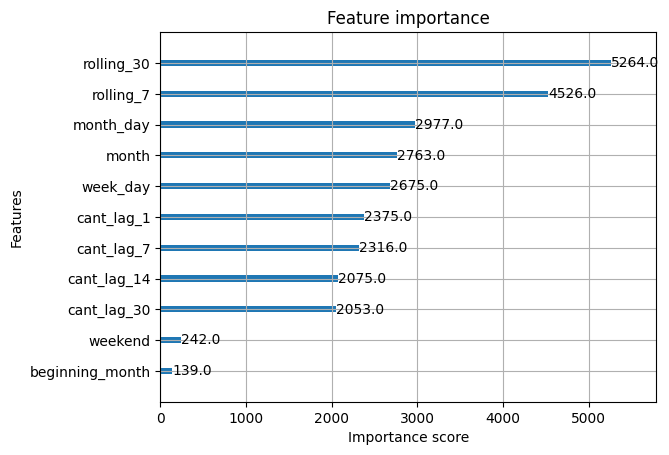

In [16]:
xgb.plot_importance(model, importance_type='weight', max_num_features=12)
plt.show()

#### Optimización del modelo

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {'n_estimators': [500, 1000, 1500],
              'learning_rate': [0.01, 0.02, 0.05, 0.1],
              'max_depth': [3,4,5,6,7,8],
              'min_child_weight': [1,2,3,5],
              'gamma': [0, 0.01, 0.1, 0.2, 0.5],
              'subsample': [0.6,0.7,0.8,0.9,1.0],
              'colsample_bytree': [0.6,0.7,0.8,0.9,1.0],
              'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
              'reg_lambda': [0.5,1,1.5,2]}

random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=param_dist,
                                   n_iter=80,
                                   scoring='neg_root_mean_squared_error',
                                   cv=tscv,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

In [18]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=1000, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=1000, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   2.0s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=1000, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   2.3s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=1000, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   2.7s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.02, max_depth=4, min_child_weight=2, n_estimators=500, reg_alpha=0.01, reg_lambda=2, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, gamma=0.2, learnin

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.01, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [19]:
random_search.best_params_

{'subsample': 0.9,
 'reg_lambda': 0.5,
 'reg_alpha': 1,
 'n_estimators': 500,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 0.7}

In [20]:
best_model = random_search.best_estimator_
best_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
y_pred_final = best_model.predict(X_test)

In [22]:
mae_final = mean_absolute_error(y_test, y_pred_final)
mae_final

0.8554466366767883

In [23]:
rmse_final = np.sqrt(((y_test - y_pred_final) ** 2).mean())
rmse_final

np.float64(2.0630126890111242)

In [24]:
r2 = r2_score(y_test, y_pred_final)
r2

0.026375234127044678

MAE ≈ 0.75
- En promedio, el modelo se equivoca en menos de 1 unidad por día y producto.

RMSE ≈ 1.96
- Penaliza más los errores grandes.
- Indica que el model capta los picos de demanda razonablemente bien.

In [25]:
mean_absolute_error(y_train, best_model.predict(X_train))

0.8580074310302734

In [26]:
mean_absolute_error(y_test, best_model.predict(X_test))

0.8554466366767883

MAE train = 0.87
MAE test  = 0.75

El modelo fue evaluado utilizando MAE y RMSE. El MAE en el conjunto de entrenamiento fue de 0.87 y en el conjunto de test de 0.75, lo que indica que el modelo generaliza correctamente y no presenta overfitting. El RMSE de 1.96 muestra que los errores grandes son poco frecuentes y están asociados a picos reales de demanda.

### Modelo Naive 

In [27]:
# Naive forecast using cant_lag_1 as prediction
y_pred_naive = X_test['cant_lag_1']

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(((y_test - y_pred_naive) ** 2).mean())

mae_naive, rmse_naive

(0.8935384615384615, np.float64(2.838851338671492))

#### Modelo Regresión lineal

In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(((y_test - y_pred_lr) ** 2).mean())

mae_lr, rmse_lr

(0.8527155839025402, np.float64(2.0641865375421076))

In [29]:
mean_absolute_error(y_train, lr.predict(X_train))

0.8652524261300472

Se utilizó un modelo naive basado en el último valor observado como línea base de comparación. Además, se entrenó un modelo de regresión lineal como benchmark simple. El modelo XGBoost superó a ambos enfoques en términos de MAE y RMSE, justificando su selección como modelo final.

In [30]:
results = pd.DataFrame({
    'Model': [
        'Naive (lag_1)',
        'Linear Regression',
        'XGBoost (final)'
    ],
    'MAE': [
        mae_naive,
        mae_lr,
        mae_final
    ],
    'RMSE': [
        rmse_naive,
        rmse_lr,
        rmse_final
    ]
})

results

,Model,MAE,RMSE
0,Naive (lag_1),0.893538,2.838851
1,Linear Regression,0.852716,2.064187
2,XGBoost (final),0.855447,2.063013


Aunque la Regresión Lineal obtuvo un valor de MAE ligeramente inferior, se seleccionó XGBoost como modelo final debido a su menor RMSE y a su mayor capacidad para capturar picos de demanda y relaciones no lineales en los datos. La diferencia en MAE entre ambos modelos es mínima y no resulta significativa desde el punto de vista del negocio, mientras que XGBoost ofrece una mayor robustez frente a valores extremos, lo cual es especialmente relevante para la optimización del stock en una farmacia.

In [31]:
with open('../models/pharmacy-demand.pkl', 'wb') as file:
    pickle.dump(model, file)